In [13]:
# Allow running from examples/ without an editable install:
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()
sys.path.insert(0, str(_root / "src"))

import gc
from casi.config import load_configs
from casi.engine import (
    run_pipeline,
    create_registry,
    get_recording_duration_ms,
    clear_data_caches,
)


# Configuration

In [ ]:
# Load configuration from configs/{paths,ops,globals}.yaml at the project root.
# Edit those files (or run "casi config edit ..." from a shell) to change defaults.
cfg = load_configs(_root / "configs")
paths_cfg = cfg.paths
ops_cfg = cfg.ops
globals_cfg = cfg.globals

from casi.config import render_summary
print(render_summary(cfg))


In [17]:
pipe = [
    "window_ms[14487.05, 44352.95]",
    # Before — no saturation handling (all 641 electrodes, no trim):
    "ca_trace(12).baseline_correction.x_corr(mea_trace(all).notch_filter.butter_bandpass.sliding_rms.gcamp_sim)",
    # Saturation survey:
    "mea_trace(all).saturation_survey",
    "mea_trace(all).saturation_survey(plot_type=scatter)",
    "mea_trace(all).saturation_survey(plot_type=survival)",
    # After — with saturation handling (drop >=30%, sync_cut, weighted circles):
    "ca_trace(12).baseline_correction.x_corr(mea_trace(all).saturation_mask.notch_filter.butter_bandpass.amp_gain_correction.sliding_rms.gcamp_sim)",
]

claude_pipe = [
    "window_ms[14487.05, 44352.95]",
    "mea_trace(861).butter_bandpass.sliding_rms.spike_pca",
    "mea_trace(861).butter_bandpass.sliding_rms.spike_pca.spike_curate(ca_trace(12).baseline_correction)",
]

bank = [
    "window_ms[15000, 16000]",
    "mea_trace(861).butter_bandpass.sliding_rms",
    ["mea_trace(861)", "mea_trace(861).butter_bandpass"],
    "mea_trace(861).butter_bandpass.spectrogram",
    "mea_trace(861).freq_traces",
    "ca_trace(11).baseline_correction.x_corr(mea_trace(all).butter_bandpass.sliding_rms.gcamp_sim)"
    "mea_trace(861).butter_bandpass.spectrogram",
    "mea_trace(861)",
    "mea_trace(815)",
    "mea_trace(861).saturation_mask",
    "mea_trace(815).saturation_mask",
]

pipeline_cfg = claude_pipe

# Run Pipeline

[cache] Cleared 5 disk cache file(s) from D:\Projects\MEA\notebooks\cache
[window] 14487.05 - 44352.95 ms
[step 1] mea_trace(861).butter_bandpass.sliding_rms.spike_pca
  Loading MEA recording from: D:\Projects\MEA\data\alignment-data\Test-B\MEA_B.raw.h5
The h5 compression library for Maxwell is already located in C:\Users\phill\hdf5_plugin_path_maxwell\compression.dll!
  spike_pca: 73 waveforms, 3 components (75.8% var), 2 outliers (2.7%)
  -> SpikePCA (1.22s)


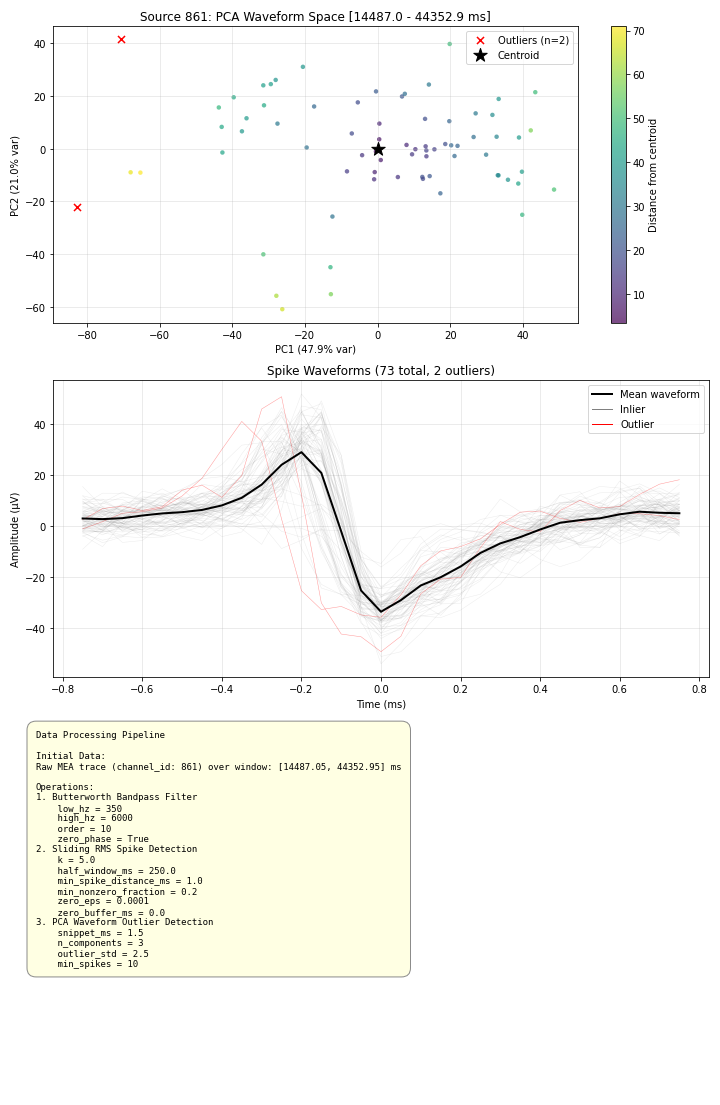

[step 2] mea_trace(861).butter_bandpass.sliding_rms.spike_pca.spike_curate(ca_trace(12).baseline_correction)
    cache hit (prefix len=3)
  Loading calcium traces from: D:\Projects\MEA\data\alignment-data\Test-B\CA_traces_B.npz
  spike_curate: removed 1/73 spikes (corr 0.2955 → 0.3050)
  -> SpikeTrain (0.27s)


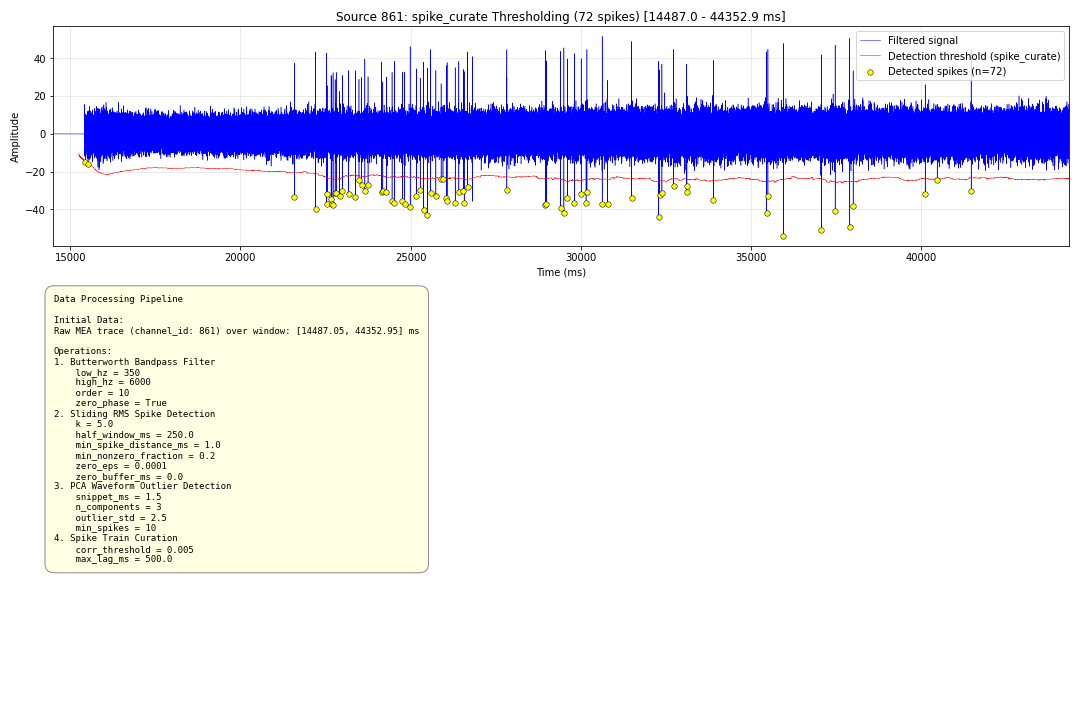

PIPELINE COMPLETE
  Steps: 3
  Total time: 2.72s (0.0 min)
  Cache: 1 hits, 2 misses, 0 disk hits
  Step timings:
    [1] mea_trace(861).butter_bandpass.sliding_rms.spike_pca: 1.22s
    [2] mea_trace(861).butter_bandpass.sliding_rms.spike_pca.spike_curate(ca_trace(12).baseline_correction): 0.27s


49

In [18]:
# Cache no longer needs to be cleared between runs - the prefix cache key
# includes ops_cfg so changing a YAML default automatically invalidates stale results.

plot_backend = globals_cfg.get("plot_backend", "matplotlib")
registry, source_loaders = create_registry(plot_backend=plot_backend)

results = run_pipeline(
    paths_cfg=paths_cfg,
    ops_cfg=ops_cfg,
    pipeline_cfg=pipeline_cfg,
    registry=registry,
    source_loaders=source_loaders,
    globals_cfg=globals_cfg,
    mea_fs_hz=20000.0,
    rtsort_fs_hz=20000.0,
    verbose=True,
    plot=True,
    get_recording_duration_ms=get_recording_duration_ms,
)

clear_data_caches()
gc.collect()
